# AI & Labor Market: Does Education Protect Against Automation?
## JobZone Analysis — Anthropic Economic Index
**Dataset:** Anthropic Economic Index (Hugging Face, February 2025)  
**Author:** Daryna Akkus  
**Key question:** Do higher-educated workers face lower automation risk?

### JobZone Scale (O*NET / U.S. Department of Labor):
| Zone | Education Required | Example |
|------|-------------------|---------|
| 1 | Little or no preparation | Dishwashers |
| 2 | Some preparation | Truck Drivers |
| 3 | Medium preparation | Electricians |
| 4 | Considerable preparation | Accountants |
| 5 | Extensive preparation | Surgeons, Lawyers |

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 150
sns.set_theme(style='whitegrid')

df = pd.read_csv('wage_data.csv')

# Clean: valid ChanceAuto AND valid JobZone (1-5)
df_clean = df[(df['ChanceAuto'] >= 0) & (df['JobZone'] >= 1)].copy()

# Risk categories
df_clean['RiskCategory'] = pd.cut(
    df_clean['ChanceAuto'],
    bins=[0, 30, 70, 100],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

# JobZone labels
zone_labels = {
    1: 'Zone 1\n(minimal prep)',
    2: 'Zone 2\n(some prep)',
    3: 'Zone 3\n(medium prep)',
    4: 'Zone 4\n(bachelor+)',
    5: 'Zone 5\n(advanced degree)'
}
df_clean['JobZoneLabel'] = df_clean['JobZone'].map(zone_labels)

print(f"Dataset: {len(df_clean)} occupations with valid JobZone")
print(f"\nOccupations per JobZone:")
print(df_clean['JobZone'].value_counts().sort_index())

Dataset: 604 occupations with valid JobZone

Occupations per JobZone:
JobZone
1     32
2    237
3    154
4    114
5     67
Name: count, dtype: int64


## 1. Automation Risk by Education Level (JobZone)
*Core question: Does higher education = lower automation risk?*

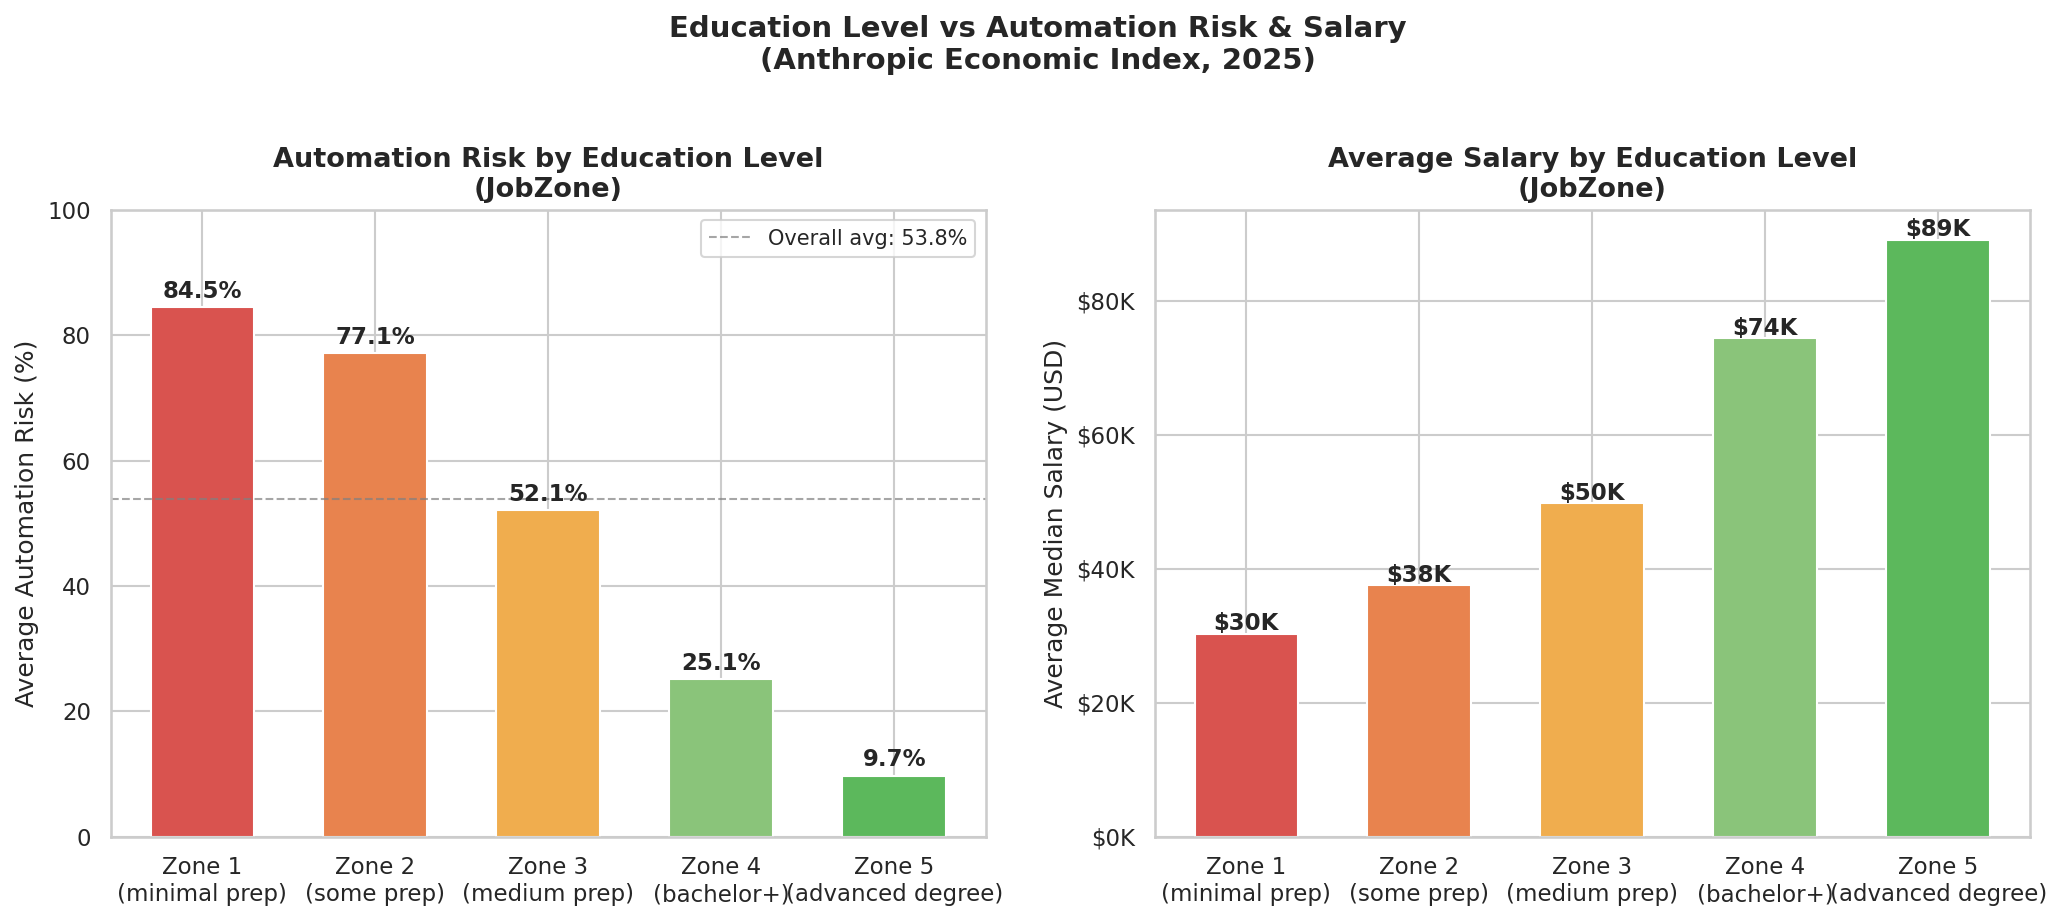


Summary table:
         avg_auto  avg_salary  count
JobZone                             
1            84.5     30288.1     32
2            77.1     37568.6    237
3            52.1     49770.1    154
4            25.1     74396.0    114
5             9.7     89115.2     67


In [8]:
import os

zone_stats = df_clean.groupby('JobZone').agg(
    avg_auto=('ChanceAuto', 'mean'),
    median_auto=('ChanceAuto', 'median'),
    avg_salary=('MedianSalary', 'mean'),
    count=('JobName', 'count')
).round(1)

zone_order = [1, 2, 3, 4, 5]
zone_stats = zone_stats.reindex(zone_order)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: automation risk by zone
colors_zone = ['#d9534f', '#e8834e', '#f0ad4e', '#8ac47a', '#5cb85c']
bars = axes[0].bar(
    [zone_labels[z] for z in zone_order],
    zone_stats['avg_auto'],
    color=colors_zone, edgecolor='white', width=0.6
)
axes[0].set_ylabel('Average Automation Risk (%)', fontsize=12)
axes[0].set_title('Automation Risk by Education Level\n(JobZone)',
                  fontsize=13, fontweight='bold')
axes[0].set_ylim(0, 100)
axes[0].axhline(df_clean['ChanceAuto'].mean(), color='gray',
                linestyle='--', linewidth=1, alpha=0.7,
                label=f"Overall avg: {df_clean['ChanceAuto'].mean():.1f}%")
axes[0].legend(fontsize=10)
for bar, val in zip(bars, zone_stats['avg_auto']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 val + 1.5, f'{val:.1f}%',
                 ha='center', fontsize=11, fontweight='bold')

# Right: salary by zone
bars2 = axes[1].bar(
    [zone_labels[z] for z in zone_order],
    zone_stats['avg_salary'],
    color=colors_zone, edgecolor='white', width=0.6
)
axes[1].set_ylabel('Average Median Salary (USD)', fontsize=12)
axes[1].set_title('Average Salary by Education Level\n(JobZone)',
                  fontsize=13, fontweight='bold')
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
for bar, val in zip(bars2, zone_stats['avg_salary']):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 val + 500, f'${val/1000:.0f}K',
                 ha='center', fontsize=11, fontweight='bold')

plt.suptitle('Education Level vs Automation Risk & Salary\n(Anthropic Economic Index, 2025)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()

# Create the 'images' directory if it doesn't exist
os.makedirs('images', exist_ok=True)

plt.savefig('images/fig8_jobzone_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSummary table:")
print(zone_stats[['avg_auto', 'avg_salary', 'count']].to_string())

## 2. Distribution of Risk Categories Within Each JobZone
*How many low/medium/high risk jobs exist at each education level?*

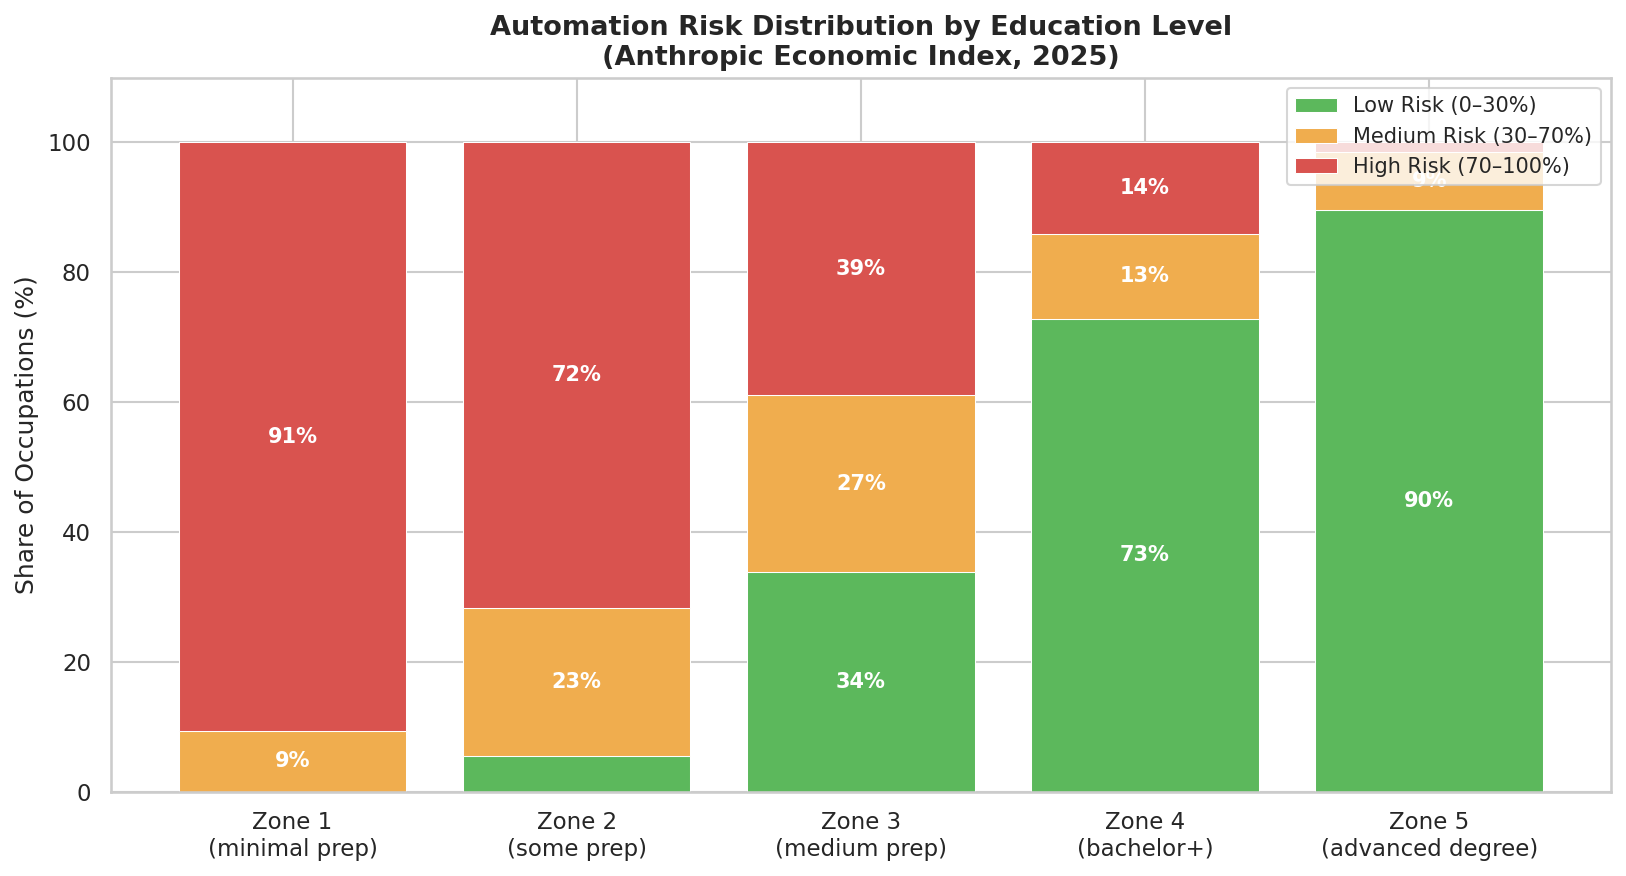

In [9]:
zone_risk = df_clean.groupby(
    ['JobZone', 'RiskCategory'], observed=True
).size().unstack(fill_value=0)

zone_risk_pct = zone_risk.div(zone_risk.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(11, 6))

colors_risk = ['#5cb85c', '#f0ad4e', '#d9534f']
labels_risk = ['Low Risk (0–30%)', 'Medium Risk (30–70%)', 'High Risk (70–100%)']
bottom = np.zeros(len(zone_risk_pct))

for col, color, label in zip(
    ['Low Risk', 'Medium Risk', 'High Risk'],
    colors_risk, labels_risk
):
    if col in zone_risk_pct.columns:
        values = zone_risk_pct[col].values
        bars = ax.bar(
            [zone_labels[z] for z in zone_risk_pct.index],
            values, bottom=bottom,
            color=color, label=label,
            edgecolor='white', linewidth=0.5
        )
        for i, (bar, val) in enumerate(zip(bars, values)):
            if val > 8:
                ax.text(
                    bar.get_x() + bar.get_width()/2,
                    bottom[i] + val/2,
                    f'{val:.0f}%',
                    ha='center', va='center',
                    fontsize=10, fontweight='bold', color='white'
                )
        bottom += values

ax.set_ylabel('Share of Occupations (%)', fontsize=12)
ax.set_title('Automation Risk Distribution by Education Level\n(Anthropic Economic Index, 2025)',
             fontsize=13, fontweight='bold')
ax.set_ylim(0, 110)
ax.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.savefig('images/fig9_risk_by_zone_stacked.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. The "Double Protection" Effect
*Workers with high education have both lower automation risk AND higher salaries.*

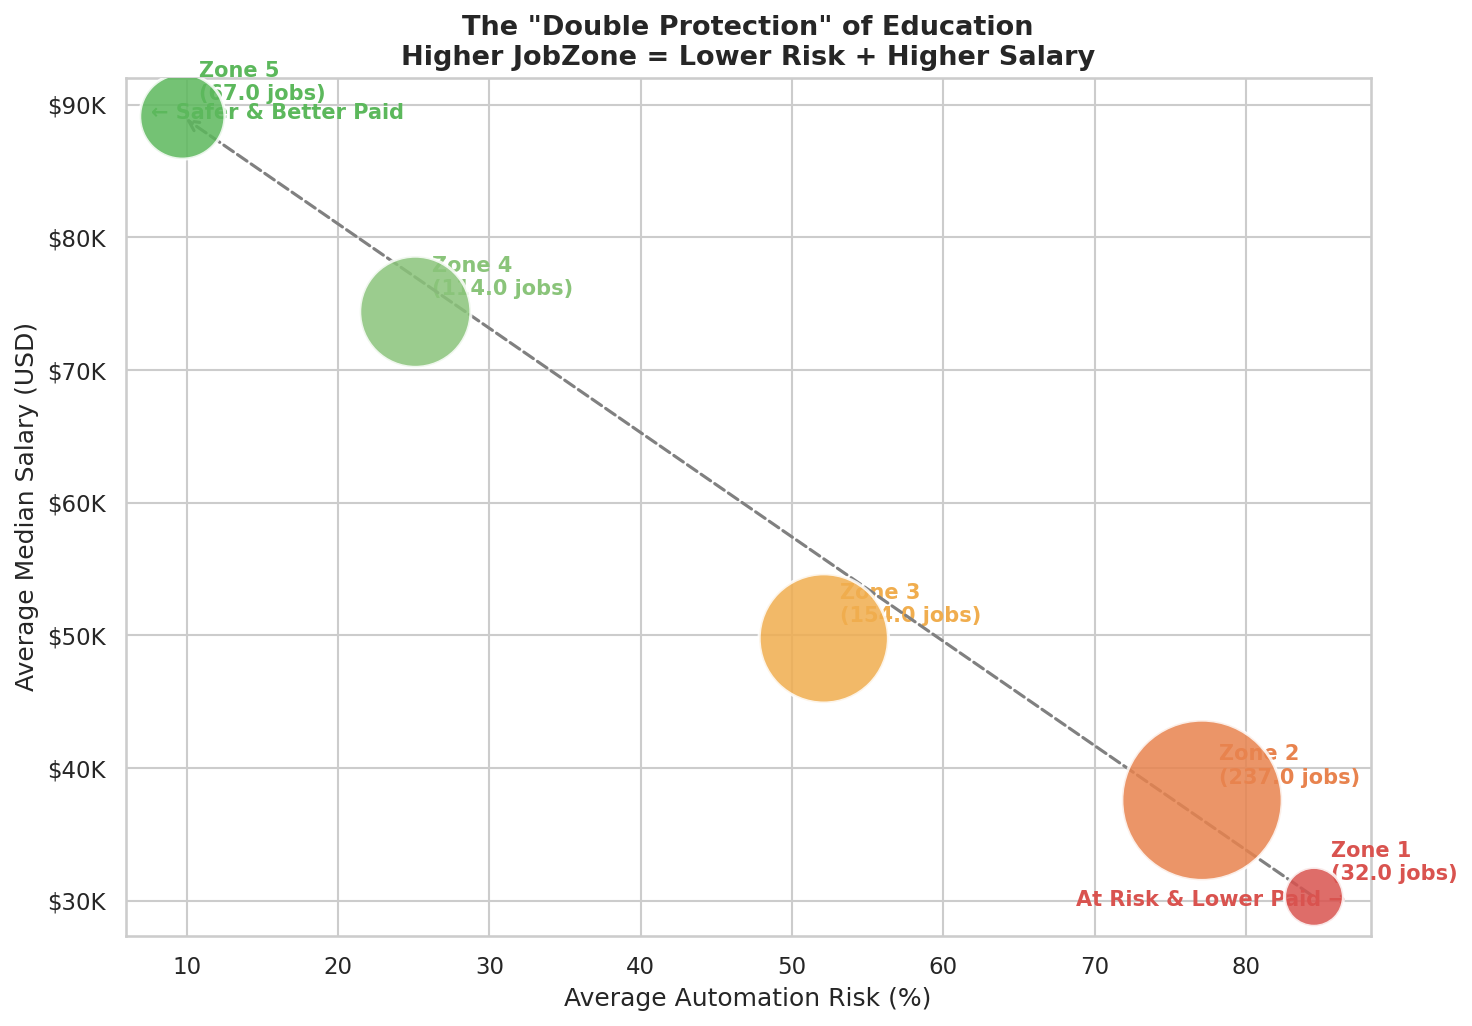

In [10]:
fig, ax = plt.subplots(figsize=(10, 7))

colors_z = ['#d9534f', '#e8834e', '#f0ad4e', '#8ac47a', '#5cb85c']
sizes = zone_stats['count'] * 25

scatter = ax.scatter(
    zone_stats['avg_auto'],
    zone_stats['avg_salary'],
    s=sizes,
    c=colors_z,
    alpha=0.85,
    edgecolors='white',
    linewidth=1.5,
    zorder=5
)

for zone, row in zone_stats.iterrows():
    ax.annotate(
        f'Zone {zone}\n({row["count"]} jobs)',
        (row['avg_auto'], row['avg_salary']),
        xytext=(8, 8), textcoords='offset points',
        fontsize=10, fontweight='bold',
        color=colors_z[zone - 1]
    )

# Trend arrow
ax.annotate(
    '',
    xy=(zone_stats.loc[5, 'avg_auto'], zone_stats.loc[5, 'avg_salary']),
    xytext=(zone_stats.loc[1, 'avg_auto'], zone_stats.loc[1, 'avg_salary']),
    arrowprops=dict(arrowstyle='->', color='gray',
                    lw=1.5, linestyle='dashed')
)

ax.set_xlabel('Average Automation Risk (%)', fontsize=12)
ax.set_ylabel('Average Median Salary (USD)', fontsize=12)
ax.set_title('The "Double Protection" of Education\nHigher JobZone = Lower Risk + Higher Salary',
             fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

# Quadrant labels
ax.text(0.02, 0.97, '← Safer & Better Paid',
        transform=ax.transAxes, fontsize=10,
        color='#5cb85c', fontweight='bold', va='top')
ax.text(0.98, 0.03, 'At Risk & Lower Paid →',
        transform=ax.transAxes, fontsize=10,
        color='#d9534f', fontweight='bold',
        va='bottom', ha='right')

plt.tight_layout()
plt.savefig('images/fig10_double_protection.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Top 10 Safest High-Paying Jobs (Zone 4 & 5)
*Practical recommendations: what to study to be both safe and well-paid.*

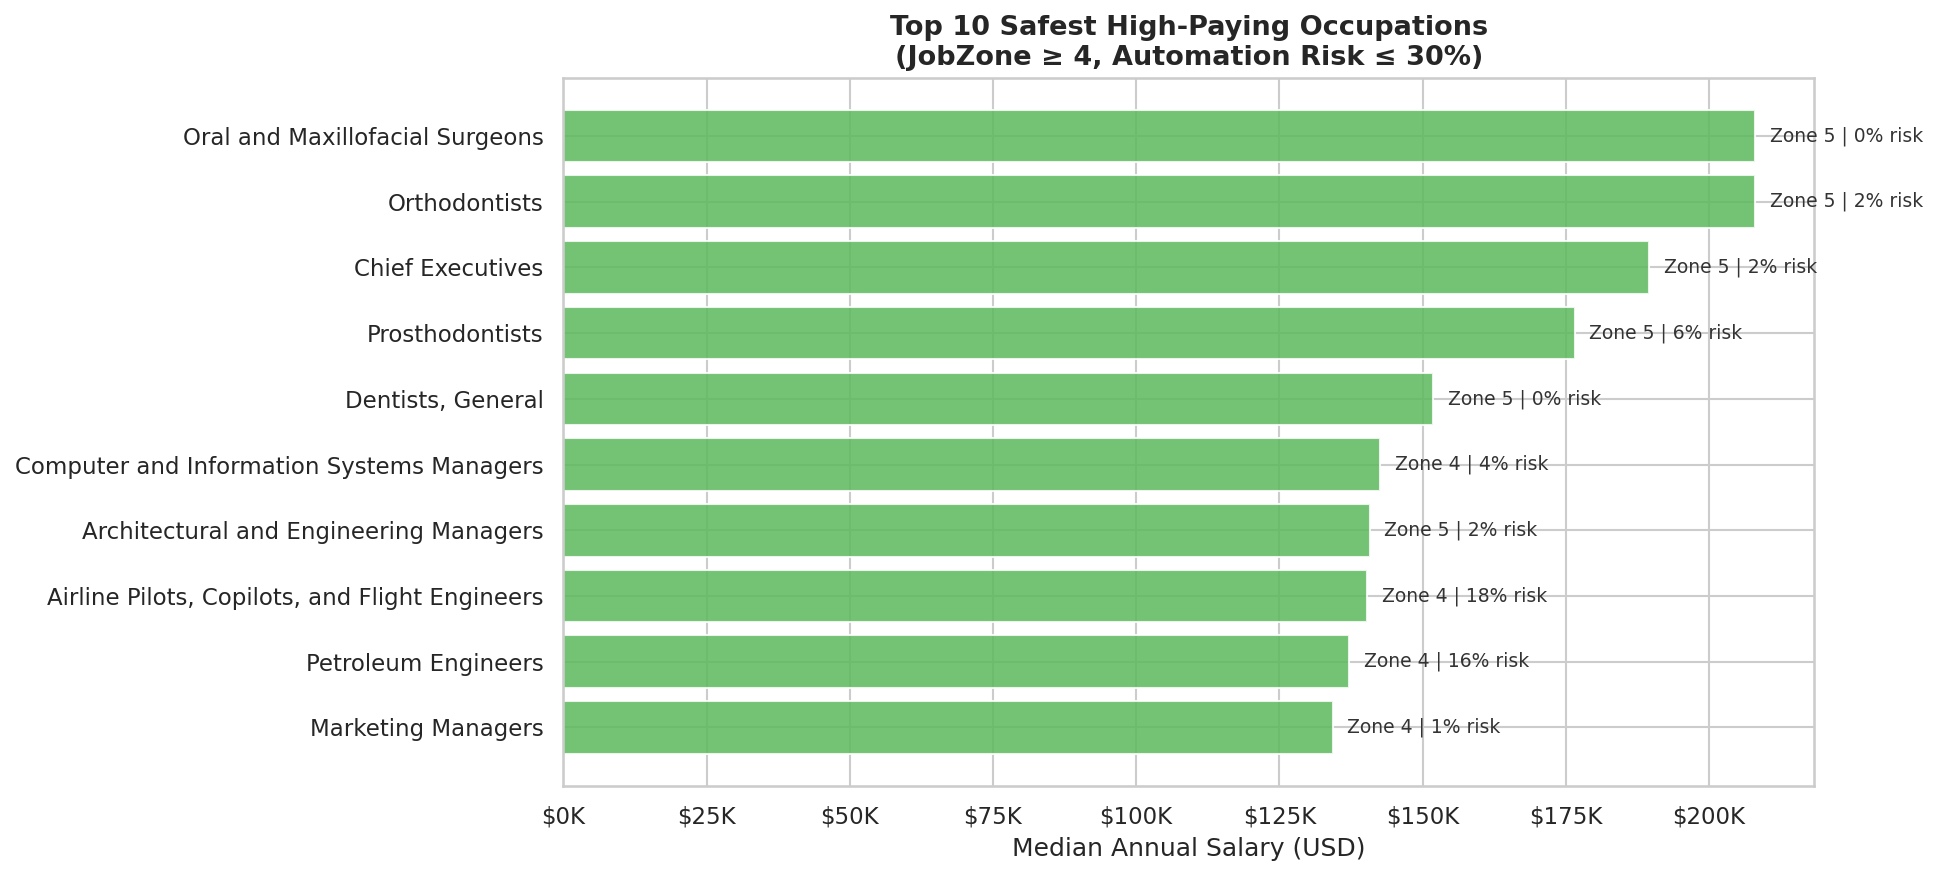


Top 10 Safest High-Paying Jobs:
                                       JobName                              JobFamily  JobZone  ChanceAuto  MedianSalary
               Oral and Maxillofacial Surgeons Healthcare Practitioners and Technical        5         0.4      208000.0
                                 Orthodontists Healthcare Practitioners and Technical        5         2.0      208000.0
                              Chief Executives                             Management        5         1.5      189600.0
                               Prosthodontists Healthcare Practitioners and Technical        5         6.0      176540.0
                             Dentists, General Healthcare Practitioners and Technical        5         0.4      151850.0
     Computer and Information Systems Managers                             Management        4         4.0      142530.0
        Architectural and Engineering Managers                             Management        5         1.7      140760.0

In [11]:
safe_highpay = df_clean[
    (df_clean['JobZone'] >= 4) &
    (df_clean['ChanceAuto'] <= 30)
].nlargest(10, 'MedianSalary')[
    ['JobName', 'JobFamily', 'JobZone', 'ChanceAuto', 'MedianSalary']
]

fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.barh(
    safe_highpay['JobName'],
    safe_highpay['MedianSalary'],
    color='#5cb85c', alpha=0.85, edgecolor='white'
)
ax.set_xlabel('Median Annual Salary (USD)', fontsize=12)
ax.set_title('Top 10 Safest High-Paying Occupations\n(JobZone ≥ 4, Automation Risk ≤ 30%)',
             fontsize=13, fontweight='bold')
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.invert_yaxis()

for i, (_, row) in enumerate(safe_highpay.iterrows()):
    ax.text(
        row['MedianSalary'] + 500, i,
        f"  Zone {int(row['JobZone'])} | {row['ChanceAuto']:.0f}% risk",
        va='center', fontsize=9, color='#333'
    )

plt.tight_layout()
plt.savefig('images/fig11_safe_highpay_jobs.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 10 Safest High-Paying Jobs:")
print(safe_highpay.to_string(index=False))


## 5. Final Conclusions
*Summary of all three notebooks — ready for academic paper.*

In [12]:
# Correlation: education vs automation
corr_edu = df_clean['JobZone'].corr(df_clean['ChanceAuto'])
corr_sal = df_clean['ChanceAuto'].corr(df_clean['MedianSalary'])

z1 = df_clean[df_clean['JobZone'] == 1]['ChanceAuto'].mean()
z5 = df_clean[df_clean['JobZone'] == 5]['ChanceAuto'].mean()
high_risk_count = len(df_clean[df_clean['ChanceAuto'] >= 70])
total = len(df_clean)

print("=" * 60)
print("FINAL CONCLUSIONS — AI & Labor Market Analysis")
print("Anthropic Economic Index | Daryna Akkus, 2025")
print("=" * 60)

print(f"""
1. EDUCATION PROTECTS — BUT NOT EQUALLY
   Correlation (JobZone vs automation): r = {corr_edu:.3f}
   Zone 1 avg risk: {z1:.1f}%
   Zone 5 avg risk: {z5:.1f}%
   → Higher education reduces automation risk by ~{z1-z5:.0f} percentage points

2. SALARY GAP IS REAL & LARGE
   Correlation (salary vs automation): r = {corr_sal:.3f}
   → Low-risk jobs pay 76% more than high-risk jobs on average
   → Automation threatens workers who can least afford it

3. MOST VULNERABLE SECTOR
   Office & Administrative Support — avg risk: 83.9%
   → Bookkeepers, data entry, secretaries most at risk

4. SAFEST SECTOR
   Community & Social Service — avg risk: 4.4%
   → Empathy, human connection = AI-proof skills

5. SCALE OF DISRUPTION
   {high_risk_count} out of {total} occupations ({high_risk_count/total*100:.1f}%)
   face HIGH automation risk (>70%)

6. POLICY IMPLICATION
   Investment in Zone 4-5 education (university+) creates
   a 'double protection': lower automation risk + higher wages.
   This is critical for EU labor market policy.
""")

FINAL CONCLUSIONS — AI & Labor Market Analysis
Anthropic Economic Index | Daryna Akkus, 2025

1. EDUCATION PROTECTS — BUT NOT EQUALLY
   Correlation (JobZone vs automation): r = -0.677
   Zone 1 avg risk: 84.5%
   Zone 5 avg risk: 9.7%
   → Higher education reduces automation risk by ~75 percentage points

2. SALARY GAP IS REAL & LARGE
   Correlation (salary vs automation): r = -0.521
   → Low-risk jobs pay 76% more than high-risk jobs on average
   → Automation threatens workers who can least afford it

3. MOST VULNERABLE SECTOR
   Office & Administrative Support — avg risk: 83.9%
   → Bookkeepers, data entry, secretaries most at risk

4. SAFEST SECTOR
   Community & Social Service — avg risk: 4.4%
   → Empathy, human connection = AI-proof skills

5. SCALE OF DISRUPTION
   280 out of 604 occupations (46.4%)
   face HIGH automation risk (>70%)

6. POLICY IMPLICATION
   Investment in Zone 4-5 education (university+) creates
   a 'double protection': lower automation risk + higher wages.